# MOwNiT 
## Laboratorium
## Wybrane zagadnienia algebry liniowej, faktoryzacja
### Algebra liniowa w Julii
https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/


In [78]:
import Pkg
Pkg.add("Polynomials")
Pkg.add("ColorTypes")
Pkg.add("Images")
Pkg.add("FileIO")
using LinearAlgebra, Plots, ColorTypes, Images, FileIO

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [79]:
methods(factorize)

# 12 methods for generic function "factorize" from LinearAlgebra:
  [1] factorize(A::Tridiagonal)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/lu.jl:583
  [2] factorize(A::SparseArrays.AbstractSparseMatrixCSC)
     @ SparseArrays ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/SparseArrays/src/linalg.jl:1746
  [3] factorize(A::Transpose)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/dense.jl:1419
  [4] factorize(A::LinearAlgebra.AbstractTriangular)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/triangular.jl:2523
  [5] factorize(A::Adjoint)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/dense.jl:1418
  [6] factorize(D::Diagonal)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/diagonal.jl:190
  [7] factorize(A::Bidiagonal)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/bidiag.jl:904
  [8] factorize(S::SymTridiagonal)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/ldlt.jl:172
  [9] factorize(A::Union{Hermitian{ComplexF64, var"#s390"}, Hermitian{Float64, var"#s390"}, Symmetric{Float64, var"#s390"}} where var"#s390"<:SparseArrays.AbstractSparseMatrixCSC)
     @ SparseArrays ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/SparseArrays/src/linalg.jl:1776
 [10] factorize(A::Union{Hermitian{T, S}, Symmetric{T, S}} where {T, S})
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/symmetric.jl:564
 [11] factorize(A::AbstractMatrix{T}) where T
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/dense.jl:1343
 [12] factorize(a::Number)
     @ ~/.julia/juliaup/julia-1.10.11+0.aarch64.apple.darwin14/Julia-1.10.app/Contents/Resources/julia/share/julia/stdlib/v1.10/LinearAlgebra/src/dense.jl:1420

In [80]:
#wiersze vs kolumny
x1=[1 2 2]

1×3 Matrix{Int64}:
 1  2  2

In [81]:
y1=[1 ;2 ;3]

3-element Vector{Int64}:
 1
 2
 3

In [82]:
transpose(x1)

3×1 transpose(::Matrix{Int64}) with eltype Int64:
 1
 2
 2

In [83]:
#iloczyn skalarny
dot(x1,y1)

11

 Długość wektora liczymy jako pierwiastek z jego iloczynu skalarnego 
$$ \lVert\mathbf{v}\rVert = \sqrt{\mathbf{v}\cdot \mathbf{v}}=\sqrt{\sum_{i=1}^nv_i^2}$$



#### Przykładowe dane

In [84]:
#losujemy macierz 3x3
A=rand(3,3)

3×3 Matrix{Float64}:
 0.307357   0.303977  0.276156
 0.317423   0.682489  0.685352
 0.0663771  0.571418  0.237056

In [85]:
#losujemy wektor x
x=rand(3)

3-element Vector{Float64}:
 0.8371750315116824
 0.13731834580680258
 0.9274101394475818

In [86]:
# wyliczamy b
b=A*x

3-element Vector{Float64}:
 0.5551627428125493
 0.9950598173925598
 0.3538835433703209

### Sposoby rozwiązania Ax=b

In [87]:
#mozemy policzyc odwrotność macierzy i wymnożyć
# uwaga: nieefektywne!
inv(A) * b

3-element Vector{Float64}:
 0.8371750315116819
 0.13731834580680255
 0.9274101394475821

In [88]:
#najlepiej używać zoptymalizowanego operatora "\""
x=A\b

3-element Vector{Float64}:
 0.8371750315116818
 0.1373183458068024
 0.9274101394475822

 operator "\\" wybiera odpowiednią faktoryzację:
- https://docs.julialang.org/en/v1.8/stdlib/LinearAlgebra/#LinearAlgebra.factorize
- https://docs.julialang.org/en/v1.8/stdlib/LinearAlgebra/#man-linalg-factorizations-1
 


### Faktoryzacja LU

In [89]:
# W przypadku ogólnej macierzy kwadratowej jest to faktoryzacja LU z pivotem
Af=factorize(A)

LU{Float64, Matrix{Float64}, Vector{Int64}}
L factor:
3×3 Matrix{Float64}:
 1.0        0.0       0.0
 0.209112   1.0       0.0
 0.968288  -0.832444  1.0
U factor:
3×3 Matrix{Float64}:
 0.317423  0.682489   0.685352
 0.0       0.428701   0.0937403
 0.0       0.0       -0.309429

In [90]:
# A*x = b <==> L * (U * x) = b -> to samo, gdzie U i L to macierze trojkatne
# dzieki temu rozwiazujemy 2 rowniania, ale mamy macierze trojkatne U i L, którymi latwiej sie rozwiazuje rownianie

# L - macierz trojkatana dolna
Af.L

3×3 Matrix{Float64}:
 1.0        0.0       0.0
 0.209112   1.0       0.0
 0.968288  -0.832444  1.0

In [91]:
#Macierz U

# U - macierz trojkatana gorna
Af.U

3×3 Matrix{Float64}:
 0.317423  0.682489   0.685352
 0.0       0.428701   0.0937403
 0.0       0.0       -0.309429

In [92]:
# wektor permulatacji wierszy 
Af.p

3-element Vector{Int64}:
 2
 3
 1

In [93]:
# mozemy zamienic macierz A na postać zfaktoryzowaną
A=factorize(A)

LU{Float64, Matrix{Float64}, Vector{Int64}}
L factor:
3×3 Matrix{Float64}:
 1.0        0.0       0.0
 0.209112   1.0       0.0
 0.968288  -0.832444  1.0
U factor:
3×3 Matrix{Float64}:
 0.317423  0.682489   0.685352
 0.0       0.428701   0.0937403
 0.0       0.0       -0.309429

In [94]:
# i działać na niej operatorem \
# operator ten będzie wykorzytywał raz utworzony wynik faktoryzacji
A\b

3-element Vector{Float64}:
 0.8371750315116818
 0.1373183458068024
 0.9274101394475822

In [95]:
# dla różnych prawych stron równania z tą samą macierzą
c=rand(3);
A\c

3-element Vector{Float64}:
  2.7974416500966197
  2.6896317142986232
 -3.853078649940168

### Faktoryzacja QR


In [96]:
B=rand(10,5)

10×5 Matrix{Float64}:
 0.294237   0.165614   0.309829  0.0657172  0.111928
 0.307538   0.162648   0.244539  0.509074   0.215635
 0.0759175  0.519509   0.453053  0.642694   0.708463
 0.1594     0.315      0.424539  0.472226   0.690423
 0.905955   0.0241039  0.715458  0.661587   0.686062
 0.392303   0.213734   0.469403  0.437971   0.385236
 0.294275   0.617898   0.106591  0.506321   0.969262
 0.737149   0.998497   0.110013  0.496599   0.221388
 0.0692947  0.382855   0.579886  0.748356   0.195245
 0.125486   0.430067   0.834708  0.23577    0.740407

In [97]:
# W przypadku ogólnej macierzy prostokątnej wybierana jest faktoryzacja QR z pivotem
factorize(B)

QRPivoted{Float64, Matrix{Float64}, Vector{Float64}, Vector{Int64}}
Q factor: 10×10 LinearAlgebra.QRPackedQ{Float64, Matrix{Float64}, Vector{Float64}}
R factor:
5×5 Matrix{Float64}:
 -1.79764  -0.884838  -1.0854    -1.24167   -1.35871
  0.0      -1.02693   -0.323349  -0.252663  -0.45321
  0.0       0.0       -0.947074   0.100256  -0.275803
  0.0       0.0        0.0        0.845181   0.332299
  0.0       0.0        0.0        0.0       -0.640041
permutation:
5-element Vector{Int64}:
 5
 1
 2
 3
 4

- $Q$ to macierz  ortogonalna mxm, co oznacza, że  $Q^T*Q=Q*Q^T=I$ czyli $Q^{-1}=Q^T$ (odwracanie takich macierzy jest szybkie i nie generuje dodatkowych błędów !)
- $R$ to macierz postaci $\begin{pmatrix} Rfactor \\ 0 \end{pmatrix} $ , gdzie $Rfactor$ jest macierzą trójkątną górną, a 0 to macierz zer o wymierze nx(m-n)

### Zastosowanie faktoryzacji do metody najmniejszych kwadratów

Jednym z zastosowań faktoryzacji QR jest użycie jej do metody najmniejszych kwadratów.

Przykład:

Obliczmy dopasowanie wielomianu $$f(x)=wsp_2*x^2+wsp_1*x+wsp_0$$ do punktów (1,1) (2,2) (3,4) (4, 4) (5,3) (6,0)

- Budujemy układ równań wg wzoru $$wsp_2x_i^2+wsp_1x_i+wsp_0=y_i$$:
$$wsp_2*1^2+wsp_1*1+wsp_0=1$$
$$wsp_2*2^2+wsp_1*2+wsp_0=2$$
$$wsp_2*3^2+wsp_1*3+wsp_0=4$$
$$wsp_2*4^2+wsp_1*4+wsp_0=4$$
$$wsp_2*5^2+wsp_1*5+wsp_0=3$$
$$wsp_2*6^2+wsp_1*6+wsp_0=0$$

- Układ ten  nie ma dokładnego rozwiązania. Możemy jednak znaleźć najlepsze przybliżenie, czyli takie $wsp_i$, które minimalizują odległość:

$$\sqrt{\sum_{i=1}^{6}{(y_i-f(x_i))^2}}=\lVert y-A*wsp\rVert$$





Jak użyć do tej mimalizacji faktoryzacji QR:

#### 1. Tworzymy macierz A na postawie $(x_i,y_i)$

In [98]:
A=zeros(6,3) 

6×3 Matrix{Float64}:
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

 punkty $(x_i,y_i)$


In [99]:
x=[1; 2 ;3 ;4 ;5 ;6]
y=[1; 2; 4; 4; 3; 0]

6-element Vector{Int64}:
 1
 2
 4
 4
 3
 0

In [100]:
A[:,1]=x.^2

6-element Vector{Int64}:
  1
  4
  9
 16
 25
 36

In [101]:
A[:,2]=x

6-element Vector{Int64}:
 1
 2
 3
 4
 5
 6

In [102]:
A[:,3]=ones(6)

6-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [103]:
A

6×3 Matrix{Float64}:
  1.0  1.0  1.0
  4.0  2.0  1.0
  9.0  3.0  1.0
 16.0  4.0  1.0
 25.0  5.0  1.0
 36.0  6.0  1.0

#### 2. Dokonujemy faktoryzacji QR macierzy A 

In [104]:
 AF=factorize(A)

QRPivoted{Float64, Matrix{Float64}, Vector{Float64}, Vector{Int64}}
Q factor: 6×6 LinearAlgebra.QRPackedQ{Float64, Matrix{Float64}, Vector{Float64}}
R factor:
3×3 Matrix{Float64}:
 -47.697  -9.24587  -1.90788
   0.0    -2.34816  -1.43091
   0.0     0.0       0.559017
permutation:
3-element Vector{Int64}:
 1
 2
 3

In [105]:
Q=Matrix(AF.Q)

6×3 Matrix{Float64}:
 -0.0209657  -0.343313    0.838525
 -0.0838628  -0.521522    0.167705
 -0.188691   -0.534625   -0.223607
 -0.335451   -0.382624   -0.33541
 -0.524142   -0.0655178  -0.167705
 -0.754765    0.416693    0.279508

In [106]:
# można przetestować ortogonalność:
Transpose(Q)*Q

3×3 Matrix{Float64}:
  1.0          9.19262e-17  -1.28002e-16
  9.19262e-17  1.0           3.12591e-17
 -1.28002e-16  3.12591e-17   1.0

Mamy równanie:
$$A*wsp=y$$
Dla $A=QR$:
$$QR*wsp =y$$
Możemy obydwie strony wymnożyć z lewej przez $Q^T$:
$$R*wsp =Q^T y$$
$$\begin{pmatrix} Rfactor \\ 0 \end{pmatrix} wsp= Q^T y$$

Poszukiwanym rozwiązaniem jest rozwiązanie równania będącego górną niezerową częścią:
$$Rfactor * wsp= Q^T y[1:n]$$
$$wsp=Rfactor \setminus Q^T y[1:n]$$

In [107]:
# implementacja powyższego (uwaga: w tym przykladzie nie jest potrzebna permutacja,
# bo wektor permutacji wynosi[1 2 3])
AF.R\((Transpose(Q)*y)[1:3])

3-element Vector{Float64}:
 -0.5714285714285727
  3.9428571428571524
 -2.8000000000000194

Więcej informacji:
- http://www.math.uconn.edu/~leykekhman/courses/MATH3795/Lectures/Lecture_8_Linear_least_squares_orthogonal_matrices.pdf
- http://www.seas.ucla.edu/~vandenbe/133A/lectures/qr.pdf

W praktyce używamy tego algorytmu poprzez operator "\\", za którym jest on "schowany".

In [108]:
A \ y

3-element Vector{Float64}:
 -0.5714285714285726
  3.9428571428571515
 -2.8000000000000176

In [109]:
#sprawdzamy czy dostaliśmy dobre wspólczynniki
using Polynomials
fit(x,y, 2)

Polynomial(-2.8000000000000176 + 3.9428571428571515*x - 0.5714285714285726*x^2)

In [110]:
@which fit

Polynomials

### Zadania

#### Zadanie 1 (1pkt)
Ustal losowe (referencyjne) x rozmiaru 1000 oraz losowe A rozmiaru 1000x1000, policz b=A*x.
Nastepnie rozwiąż równanie Ax=b trzema metodami:
- inv()
- \
- factorize()

Porównaj jakość wyniku (zmierzoną jako długość różnicy wektorów wyniku oraz referencyjnego x) oraz czas wykonania (@time). UWAGA: pierwsze wykonanie funkcji w Julii zawiera czas kompilacji tej funkcji, dlatego czas mierzymy  od drugiego wywołania !

#### Zadanie 2 (1pkt)
Policz współczynniki wielomianu aproksymującego dowolne dane z poprzednich laboratoriów tworząc wprost układ równań i rozwiązujac go (metoda z użyciem faktoryzacji QR zaprezentowana na tym laboratorium).
Porównaj wyniki z tymi otrzymanymi poprzednio.

#### Zadanie 3 (2 pkt)

Znajdź i zaprezentuj działanie innego zastosowania wybranej faktoryzacji. Przykładowe (ale nie jedyne!) tematy:

-    tworzenie pseudoinversji macierzy (http://buzzard.ups.edu/courses/2014spring/420projects/math420-UPS-spring-2014-macausland-pseudo-inverse-present.pdf).

-   uzycie faktoryzacji QR do znajdowania wartości własnych (https://en.wikipedia.org/wiki/QR_algorithm)

-  zastosowanie faktoryzacji SVD - np. zastosowania w uczeniu maszynowym 



In [111]:
using Polynomials, LinearAlgebra, Plots,DataFrames,CSV

### Zadanie 1

In [112]:
x = rand(1000)
A = rand(1000,1000)
b = A*x
df = DataFrame(Method=String[],Difference=Float64[],Time=Float64[])

invMethod = x - inv(A)*b
res1 = norm(invMethod)
# @elapsed nie wlicza czasu kompilacji przy pierwszym wywolaniu funkcji
time1 = @elapsed inv(A)*b
push!(df,("inv()",res1,time1))

normMethod = x - A\b
res2 = norm(normMethod)
time2 = @elapsed A\b
push!(df,("/",res2,time2))

Af = factorize(A)
factMethod = x - Af\b
res3 = norm(factMethod)
time3 = @elapsed factorize(A)\b
push!(df,("factorize()",res3,time3))

df

# Analiza wykresu:
# Czasu jest duzo większy dla uzycia inv() co udowadnia zalozienie, ktore wystepuje w opisie laboratorium
# / i factorize() daja identyczny wynik w postaci roznicy wyniku, przy lekko roznym czasie, jest to spowodane srodowiskiem testowym
# jakim jest komputer z procesami dzialajacymi w tle. Przez to ze / wybiera algorytm LU ktory jest wykorzystany w factorize()

Row,Method,Difference,Time
,String,Float64,Float64
1,inv(),1.93214e-11,0.0332357
2,/,9.64765e-12,0.00792421
3,factorize(),9.64765e-12,0.0101935


### Zadanie 2

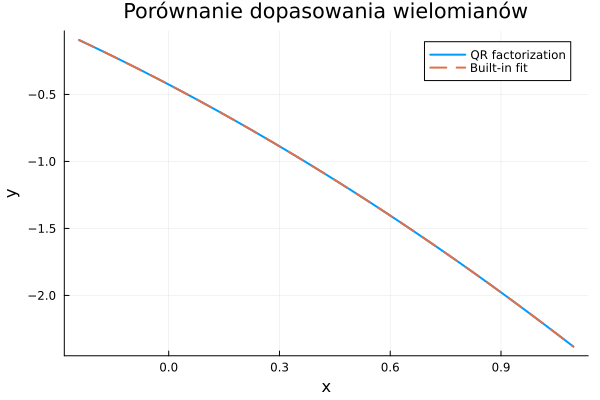

In [144]:
using CSV, DataFrames, LinearAlgebra, Polynomials, Plots
# Stosuje wzor QR podany w konspekcie laboratorium

# Wczytanie danych z pliku
data = CSV.read("ecg_data.csv", DataFrame)
x = data.signalN         # zmienna niezależna
y = data.signalV         # zmienna zależna

# Zbudowanie macierzy projektującej dla wielomianu stopnia 2: [x^2 x 1]
design_matrix = zeros(length(x), 3)
design_matrix[:, 1] = x .^ 2
design_matrix[:, 2] = x
design_matrix[:, 3] .= 1.0

# Rozkład QR i rozwiązanie układu równań metodą najmniejszych kwadratów
qr_fact = factorize(design_matrix)
QTy = qr_fact.Q' * y
coefficients = qr_fact.R \ QTy[1:3]

# Utworzenie wielomianu z obliczonymi współczynnikami
qr_poly = Polynomial(coefficients)

# Dopasowanie wielomianu przy użyciu funkcji pakietowej (do porównania)
builtin_poly = fit(x, y, 2)

# Wizualizacja wyników
plot_range = extrema(x)
plot(qr_poly, plot_range..., label="QR factorization", lw=2)
plot!(builtin_poly, plot_range..., label="Built-in fit", lw=2, linestyle=:dash)
xlabel!("x")
ylabel!("y")
title!("Porównanie dopasowania wielomianów")

### Zadanie 3: Zastosowanie faktoryzacji SVD do aproksymacji obrazu

W tym zadaniu pokazuję, jak można wykorzystać **faktoryzację SVD** do uproszczenia obrazu przy jednoczesnym zachowaniu jego najważniejszych cech.

SVD rozkłada macierz obrazu $A$ na trzy składniki:

$$A = U \Sigma V^T$$

Gdzie:
* $U$ i $V$ to macierze ortogonalne (reprezentujące "rotacje" przestrzeni),
* $\Sigma$ to macierz diagonalna zawierająca tzw. **wartości osobliwe** (*singular values*), posortowane malejąco od największej do najmniejszej.

Wartości osobliwe informują nas o tym, które części danych niosą najwięcej znaczenia:
* **Największe wartości** odpowiadają głównym cechom i strukturze obrazu.
* **Najmniejsze wartości** reprezentują mało istotne detale lub szum cyfrowy.

Zamiast używać pełnego zestawu informacji, możemy wziąć tylko $k$ największych wartości osobliwych i odtworzyć skompresowaną, przybliżoną wersję obrazu (tzw. aproksymację rzędu $k$):

$$A_k \approx U_k \Sigma_k V_k^T$$

Im większa wartość parametru $k$, tym lepsze i dokładniejsze przybliżenie oryginału. Na wygenerowanym wykresie prezentuję obraz po odtworzeniu dla $k = 100$. Chociaż wykorzystujemy tylko niewielką część początkowych informacji, zrekonstruowany obraz wciąż prezentuje się bardzo dobrze i jest w pełni czytelny.

---

> **Wniosek:** SVD udowadnia, że wiele informacji da się drastycznie uprościć bez zauważalnej utraty jakości wizualnej.

Takie podejście numeryczne jest powszechnie wykorzystywane w inżynierii i informatyce, między innymi w:
* Kompresji obrazów i danych,
* Redukcji szumu z sygnałów,
* Uczeniu maszynowym (PCA)


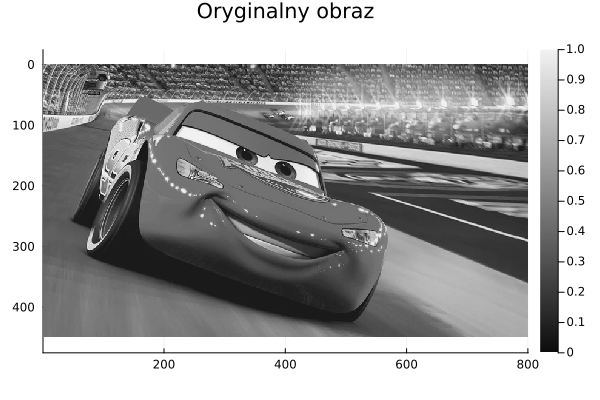

In [146]:
# Faktoryzacja SVD i kompresja do k składowych
function compress_image_svd(A, k)
    U, S, V = svd(A)
    U[:, 1:k] * Diagonal(S[1:k]) * V[:, 1:k]'
end

# Ładowanie obrazu
A = Float64.(Gray.(load("zygzak.png")))

# Wyświetlenie oryginalnego obrazu oddzielnie
heatmap(A, color=:grays, title="Oryginalny obraz", aspect_ratio=1, yflip=true)

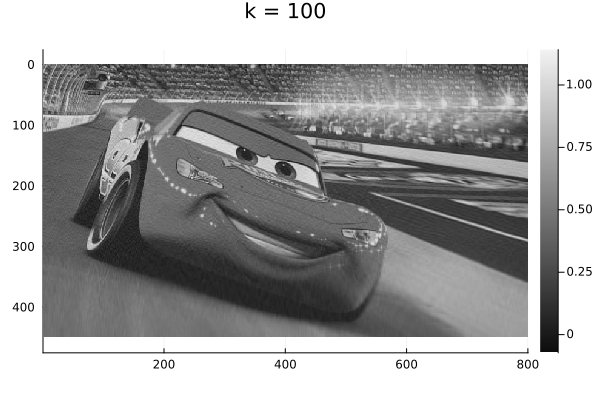

In [134]:


# Rysujemy oryginał i kompresje dla różnych k
plot(layout=(2, 3), size=(1000, 600))
k = 100

Ak = compress_image_svd(A, k)
plot!(heatmap(Ak, color=:grays, title="k = $k", aspect_ratio=1, yflip=true))


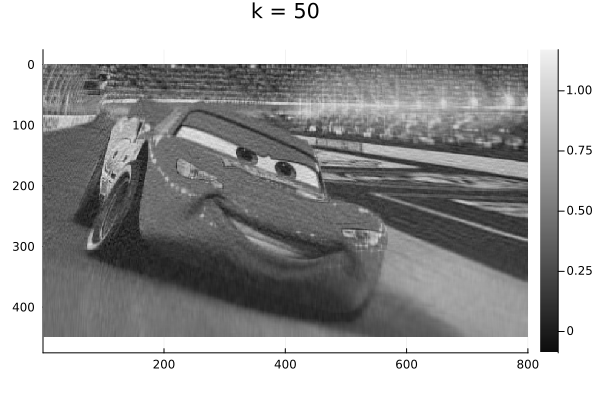

In [135]:
plot(layout=(2, 3), size=(1000, 600))
k = 50

Ak = compress_image_svd(A, k)
plot!(heatmap(Ak, color=:grays, title="k = $k", aspect_ratio=1, yflip=true))

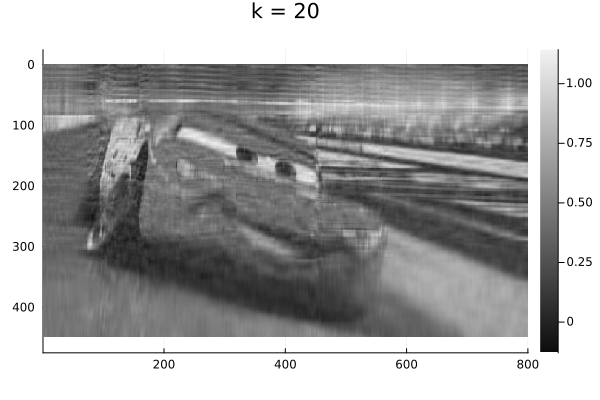

In [136]:
plot(layout=(2, 3), size=(1000, 600))
k = 20

Ak = compress_image_svd(A, k)
plot!(heatmap(Ak, color=:grays, title="k = $k", aspect_ratio=1, yflip=true))

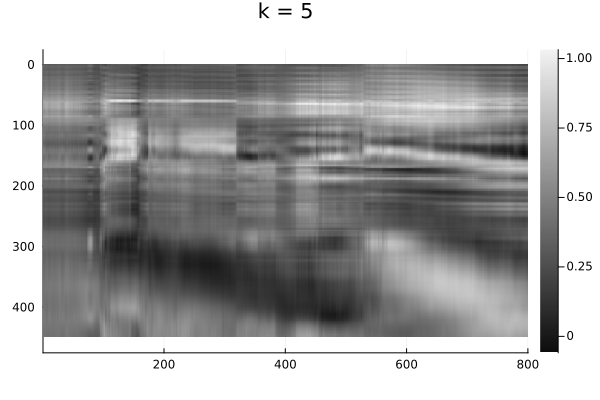

In [137]:
plot(layout=(2, 3), size=(1000, 600))
k = 5

Ak = compress_image_svd(A, k)
plot!(heatmap(Ak, color=:grays, title="k = $k", aspect_ratio=1, yflip=true))

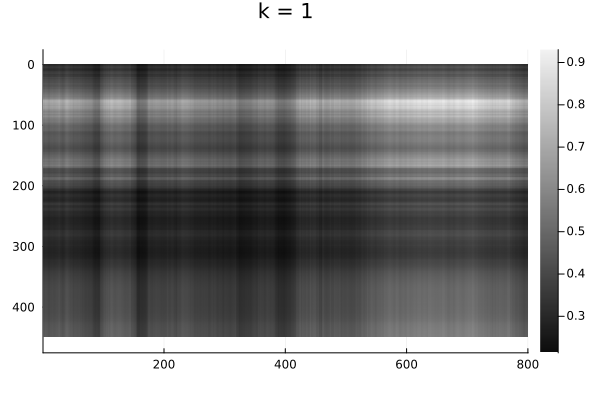

In [138]:
plot(layout=(2, 3), size=(1000, 600))
k = 1

Ak = compress_image_svd(A, k)
plot!(heatmap(Ak, color=:grays, title="k = $k", aspect_ratio=1, yflip=true))